In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
import equinox as eqx
import esm  # pip install fair-esm==2.0.0
import esm2quinox
import jax.random as jrandom
import optax  # pip install optax
from dataset.dataset import initialize_datasets, Dataset_PEPBI
from functions.model import AFF_PREDICTOR
from functions.training import train_model, eval_step
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax.random as jr
import jax
import pandas as pd
from torch.utils.data import DataLoader
import jax.tree_util as jtu

In [4]:
# # initialize the dataloader
# train_loader, val_loader, test_loader = initialize_datasets(
#     paths=[
#         "/home/kunzj/dataset/final_csv/train.csv",
#         "/home/kunzj/dataset/final_csv/validation.csv",
#         "/home/kunzj/dataset/final_csv/test.csv",
#     ],
#     batches=[5, 3, 1],
# )

In [5]:
data_train = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/pepbi/min_max_scaled/train_data_pepbi.csv",
    transform=esm2quinox.tokenise
)
train_loader = DataLoader(data_train,batch_size=3)

<Axes: ylabel='Density'>

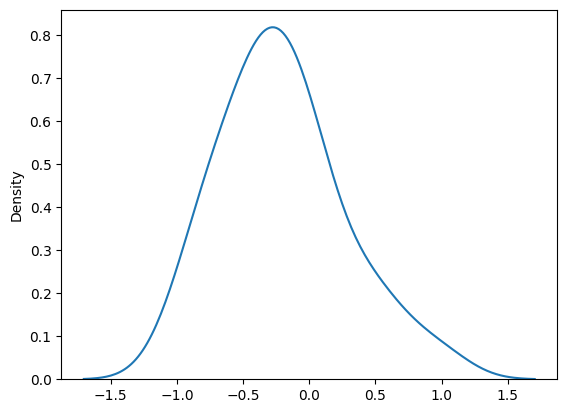

In [6]:
sns.kdeplot(data_train.aff_Vals)

In [7]:
# generating keys
model_key, call_key = jr.split(jrandom.PRNGKey(0), 2)

# initializing models
torch_model, _ = esm.pretrained.esm2_t6_8M_UR50D()
model_esm2 = esm2quinox.from_torch(torch_model)
model_aff, model_state = eqx.nn.make_with_state(AFF_PREDICTOR)(
    model=model_esm2, key=model_key
)

# initializing optimizer
optim = optax.adam(learning_rate=0.001)
opt_state = optim.init(eqx.filter(model_aff, eqx.is_inexact_array))


/home/jkunz/master_uni_hd/internship_amsterdam/work/lib/python3.10/site-packages/equinox/nn/_batch_norm.py:132: UserWarning: When `eqx.nn.BatchNorm(..., mode=...)` is unspecified it defaults to 'ema', for backward compatibility. This typically has a performance impact, and for new code the user is encouraged to use 'batch' instead. See `https://github.com/patrick-kidger/equinox/issues/659`.
  warnings.warn(


In [18]:
#eqx.tree_serialise_leaves('/home/jkunz/master_uni_hd/internship_amsterdam/carbon/BindCraft_uva_internship/notebooks/test.txt',model_aff)

In [11]:
target_str =['QPRGGGPTSSEQIMKTGALLLQGFIQDRAGRMGGEAPELALDPVPQDASTKKLSECLKRIGDELDSNMELQRMIAAVDTDSPREVFFRVAADMFSDGNFNWGRVVALFYFASKLVLKALCTKVPELIRTIMGWTLDFLRERLLGWIQDQGGWDGLLSYFG']
x_prot = esm2quinox.tokenise(target_str)

In [12]:
x_prot

array([[ 0, 16, 14, 10,  6,  6,  6, 14, 11,  8,  8,  9, 16, 12, 20, 15,
        11,  6,  5,  4,  4,  4, 16,  6, 18, 12, 16, 13, 10,  5,  6, 10,
        20,  6,  6,  9,  5, 14,  9,  4,  5,  4, 13, 14,  7, 14, 16, 13,
         5,  8, 11, 15, 15,  4,  8,  9, 23,  4, 15, 10, 12,  6, 13,  9,
         4, 13,  8, 17, 20,  9,  4, 16, 10, 20, 12,  5,  5,  7, 13, 11,
        13,  8, 14, 10,  9,  7, 18, 18, 10,  7,  5,  5, 13, 20, 18,  8,
        13,  6, 17, 18, 17, 22,  6, 10,  7,  7,  5,  4, 18, 19, 18,  5,
         8, 15,  4,  7,  4, 15,  5,  4, 23, 11, 15,  7, 14,  9,  4, 12,
        10, 11, 12, 20,  6, 22, 11,  4, 13, 18,  4, 10,  9, 10,  4,  4,
         6, 22, 12, 16, 13, 16,  6,  6, 22, 13,  6,  4,  4,  8, 19, 18,
         6,  2]])

In [19]:
# train model
best_model, train_losses,model_state = train_model(
    training_DataLoader=train_loader,
    max_epochs=3,
    model_aff=model_aff,
    model_state= model_state,
    opt_state=opt_state,
    optim=optim,
    key=call_key,
)

Training-Set:   0%|          | 0/11 [00:00<?, ?it/s]

Epochs: 100%|██████████| 3/3 [00:38<00:00, 12.99s/it]

Training complete.


test

In [20]:
train_losses

[0.06243302673101425, 0.03156837448477745, 0.081796795129776]

In [21]:
data_test = Dataset_PEPBI(
    columns=["Prot_Seq", "Pept_Seq", "Energy"],
    data_path="/home/jkunz/master_uni_hd/internship_amsterdam/BindCraft_uva_internship/data/pepbi/min_max_scaled/test_data_pepbi.csv",
    transform=esm2quinox.tokenise
)
test_loader = DataLoader(data_test,batch_size=1)
test_key_init = jrandom.PRNGKey(1)

<Axes: ylabel='Density'>

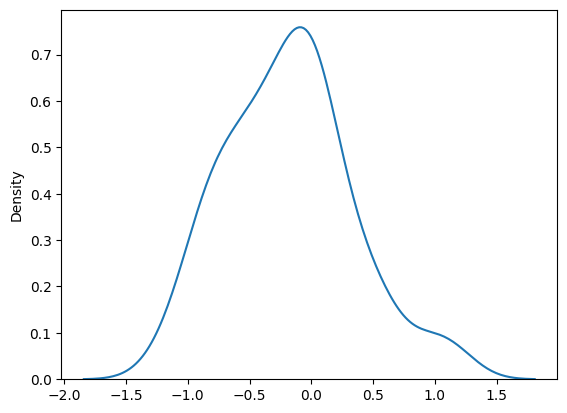

In [22]:
sns.kdeplot(data_test.aff_Vals)

In [23]:
inference_model = eqx.nn.inference_mode(best_model)
inference_model = eqx.Partial(inference_model, state=model_state)

test_loss_list = []

for entry, (x_prot,x_pept, y_val) in enumerate(test_loader):
    
    x_prot,x_pept, y_val = jnp.array(x_prot),jnp.array(x_pept), jnp.array(y_val)
    test_key = jr.split(test_key_init,x_pept.shape[0])
    test_loss, pred_y = eval_step(inference_model, x_prot,x_pept, y_val,test_key)
    test_loss_list.append(test_loss.item())

    print(
        f"[Entry {entry + 1}] , Test Loss: {test_loss:.3f}, Predicted Y: {pred_y.item():.3f}, , True Y: {y_val.item():.3f}"
    )


[Entry 1] , Test Loss: 0.930, Predicted Y: -0.118, , True Y: 0.846
[Entry 2] , Test Loss: 0.449, Predicted Y: -0.180, , True Y: -0.850
[Entry 3] , Test Loss: 0.070, Predicted Y: -0.337, , True Y: -0.071
[Entry 4] , Test Loss: 0.482, Predicted Y: -0.255, , True Y: -0.949
[Entry 5] , Test Loss: 1.611, Predicted Y: -0.224, , True Y: 1.046
[Entry 6] , Test Loss: 1.674, Predicted Y: -0.244, , True Y: 1.049
[Entry 7] , Test Loss: 0.042, Predicted Y: -0.210, , True Y: -0.005
[Entry 8] , Test Loss: 0.110, Predicted Y: -0.218, , True Y: 0.113
[Entry 9] , Test Loss: 0.026, Predicted Y: -0.204, , True Y: -0.043
[Entry 10] , Test Loss: 0.223, Predicted Y: -0.249, , True Y: 0.223
[Entry 11] , Test Loss: 0.046, Predicted Y: -0.204, , True Y: 0.011
[Entry 12] , Test Loss: 0.005, Predicted Y: -0.128, , True Y: -0.198
[Entry 13] , Test Loss: 0.002, Predicted Y: -0.263, , True Y: -0.303
[Entry 14] , Test Loss: 0.085, Predicted Y: -0.243, , True Y: 0.048
[Entry 15] , Test Loss: 0.212, Predicted Y: -0.212

In [24]:
model_aff

AFF_PREDICTOR(
  esm2=ESM2(
    num_layers=6,
    embed_size=320,
    num_heads=20,
    token_dropout=True,
    layers=TransformerLayer(
      embed_size=320,
      hidden_size=1280,
      num_heads=20,
      attn=MultiheadAttention(
        query_proj=Linear(
          weight=f32[6,320,320],
          bias=f32[6,320],
          in_features=320,
          out_features=320,
          use_bias=True
        ),
        key_proj=Linear(
          weight=f32[6,320,320],
          bias=f32[6,320],
          in_features=320,
          out_features=320,
          use_bias=True
        ),
        value_proj=Linear(
          weight=f32[6,320,320],
          bias=f32[6,320],
          in_features=320,
          out_features=320,
          use_bias=True
        ),
        output_proj=Linear(
          weight=f32[6,320,320],
          bias=f32[6,320],
          in_features=320,
          out_features=320,
          use_bias=True
        ),
        dropout=Dropout(p=0.0, inference=False),
        nu